# LNG Ship Voyage — Multi-Tank Q-Max Carrier

This notebook models a full Q-Max LNG carrier voyage from Ras Laffan (Qatar) to
Futtsu (Japan) with:

- **4 membrane tanks** (174,000 m³ each, total ~266,000 m³ LNG at 98% fill)
- **Shared BOG handling network** — fuel for DFDE, reliquefaction, and GCU
- **Realistic voyage profile** with environment segments
- **Aggregate ship-level KPIs** — total BOG, cargo loss, mass-weighted quality

In [1]:
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except Exception:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim2
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim2\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim2\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim2\target\neqsim-3.7.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jpype

# Import Java classes (works with both devtools and pip modes)
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")

# LNG classes
LNGShipModel = jpype.JClass("neqsim.process.equipment.lng.LNGShipModel")
LNGAgeingScenario = jpype.JClass("neqsim.process.equipment.lng.LNGAgeingScenario")
LNGBOGHandlingNetwork = jpype.JClass("neqsim.process.equipment.lng.LNGBOGHandlingNetwork")
LNGVoyageProfile = jpype.JClass("neqsim.process.equipment.lng.LNGVoyageProfile")
TankGeometry = jpype.JClass("neqsim.process.equipment.lng.TankGeometry")
MethaneNumberCalculator = jpype.JClass("neqsim.process.equipment.lng.MethaneNumberCalculator")
Segment = jpype.JClass("neqsim.process.equipment.lng.LNGVoyageProfile$Segment")

print("All classes imported")


All classes imported


## 1. Define the LNG Cargo

We use a typical Qatargas blend — lean LNG with high methane fraction.

In [3]:
def create_lng_cargo():
    lng = SystemSrkEos(111.5, 1.013)
    lng.addComponent("methane", 0.910)
    lng.addComponent("ethane", 0.058)
    lng.addComponent("propane", 0.018)
    lng.addComponent("i-butane", 0.005)
    lng.addComponent("n-butane", 0.003)
    lng.addComponent("nitrogen", 0.006)
    lng.setMixingRule("classic")
    feed = Stream("LNG cargo", lng)
    feed.setFlowRate(174000.0, "m3/hr")
    feed.run()
    return feed

print("Cargo definition ready")

Cargo definition ready


## 2. Create the Ship Model

The `LNGShipModel` manages 4 parallel `LNGAgeingScenario` instances
with a shared `LNGBOGHandlingNetwork` for BOG disposition.

In [4]:
feed = create_lng_cargo()

ship = LNGShipModel("Q-Max Carrier")
ship.setSimulationTime(480.0)   # 20 days
ship.setTimeStepHours(4.0)

# Create 4 identical tank scenarios
for i in range(4):
    tank = LNGAgeingScenario(f"Tank {i+1}", feed)
    tank.setTankVolume(66500.0)  # per tank; total ~266,000 m3
    tank.setInitialFillingRatio(0.98)
    tank.setOverallHeatTransferCoeff(0.045)
    tank.setTankPressure(1.013)
    ship.addTank(tank)

# Shared BOG network
bog = LNGBOGHandlingNetwork()
bog.setFuelGasConsumptionRate(3600.0)  # kg/hr fuel demand
bog.setReliquefactionCapacity(3000.0)  # kg/hr
bog.setReliquefactionEfficiency(0.92)
bog.setGcuCapacity(2000.0)  # kg/hr
ship.setBogNetwork(bog)

# Voyage profile
profile = LNGVoyageProfile("Ras Laffan - Futtsu")
profile.addSegment(Segment(0,    72,  311.15, 0.5,   8.0, 850.0))  # Persian Gulf
profile.addSegment(Segment(72,  168,  307.15, 1.5,  15.0, 750.0))  # Indian Ocean
profile.addSegment(Segment(168, 288,  303.15, 2.0,  18.0, 600.0))  # Strait of Malacca
profile.addSegment(Segment(288, 408,  298.15, 2.5,  20.0, 500.0))  # South China Sea
profile.addSegment(Segment(408, 480,  289.15, 1.0,  10.0, 350.0))  # Japan approach
ship.setVoyageProfile(profile)

n_tanks = len(list(ship.getTankScenarios()))
print(f"Ship configured: {n_tanks} tanks, total {n_tanks * 66500:.0f} m3")


Ship configured: 4 tanks, total 266000 m3


In [5]:
# Run the multi-tank simulation
ship.run()

print(ship.getShipSummary())

# Get aggregate results
ship_results = list(ship.getShipResults())
cargo_loss_pct = ship.getTotalCargoLossPct()
last_sr = ship_results[-1]

print(f"\nTotal cargo loss: {cargo_loss_pct:.2f}%")
print(f"Final avg Wobbe index: {last_sr.averageWobbeIndex:.2f} MJ/Sm3")
print(f"Final avg MN: {last_sr.averageMN:.1f}")
print(f"Final total BOG rate: {last_sr.totalBOGRate:.0f} kg/hr")


=== LNG Ship Model Summary ===
Ship: Q-Max Carrier, Tanks: 4
Duration: 480.0 hours (20.0 days)

--- Initial vs Final (Ship Totals) ---
Total liquid mass: 0 -> 118240 tonnes (loss: 0.00%)
Avg density: 0.0 -> 645.6 kg/m3
Avg WI: 0.00 -> 44.31 MJ/Sm3
Avg MN: 0.0 -> 123.4
Total BOG rate (final): 2845 kg/hr


Total cargo loss: 0.00%
Final avg Wobbe index: 44.31 MJ/Sm3
Final avg MN: 123.4
Final total BOG rate: 2845 kg/hr


## 3. Per-Tank Analysis

Compare how the 4 tanks evolve (they share the same conditions in this
configuration, but could differ if individual heat transfers vary).

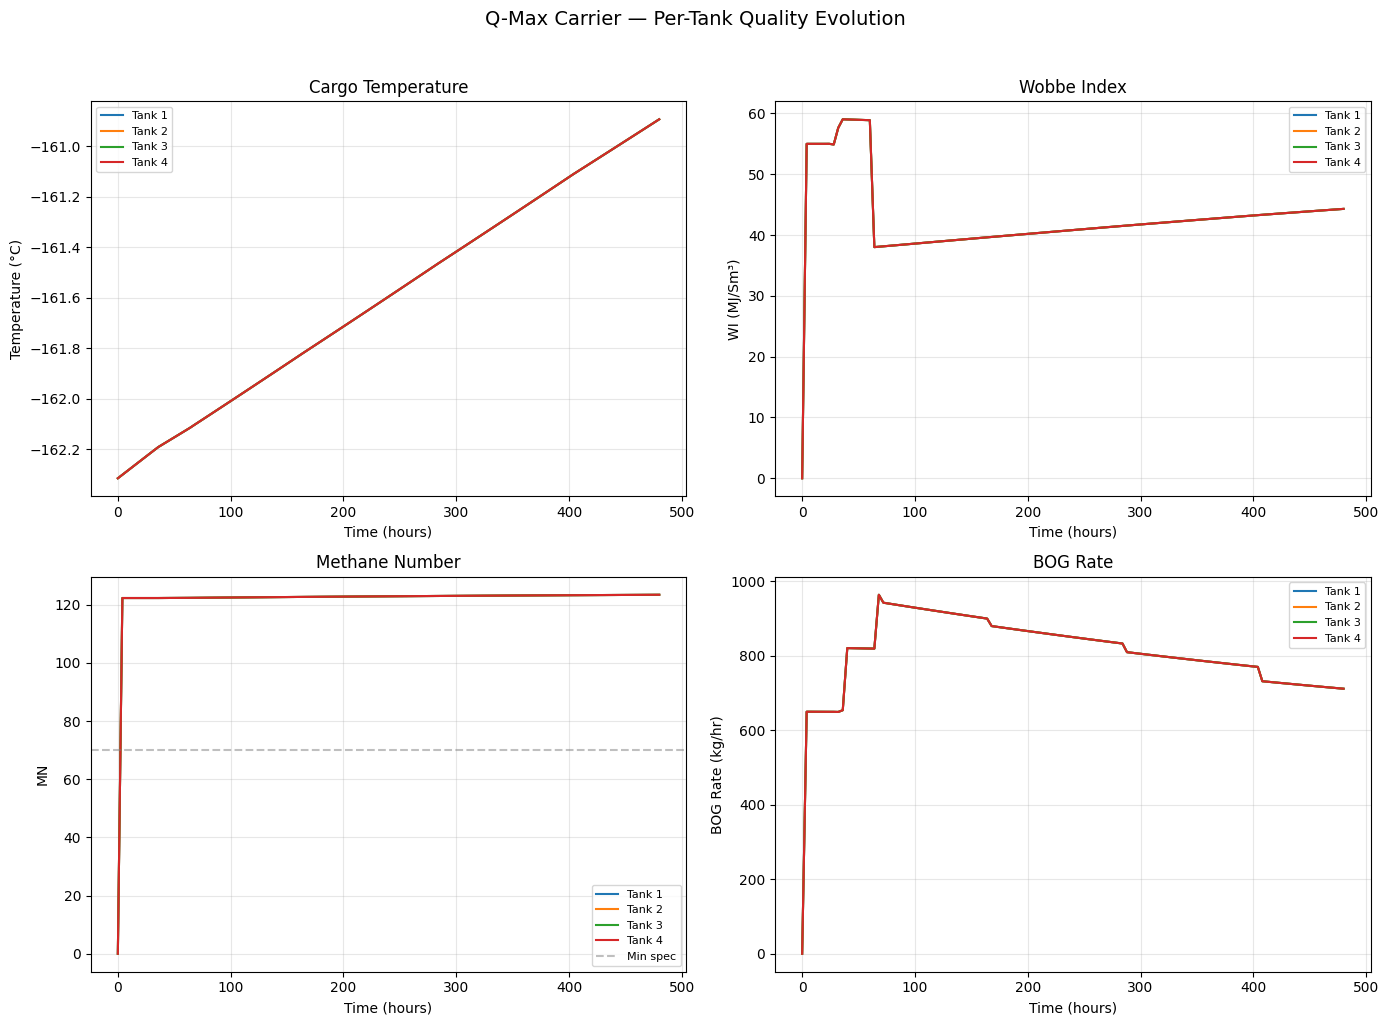

In [6]:
# Collect per-tank time series
tank_scenarios = list(ship.getTankScenarios())
n_tanks = len(tank_scenarios)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tank_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, sc in enumerate(tank_scenarios):
    results = list(sc.getResults())
    times = [r.getTimeHours() for r in results]
    temps = [r.getTemperature() - 273.15 for r in results]
    wis = [r.getWobbeIndex() for r in results]
    mns = [r.getMethaneNumber() for r in results]
    bogs = [r.getBogMassFlowRate() for r in results]

    c = tank_colors[i]
    axes[0,0].plot(times, temps, color=c, linewidth=1.5, label=f'Tank {i+1}')
    axes[0,1].plot(times, wis, color=c, linewidth=1.5, label=f'Tank {i+1}')
    axes[1,0].plot(times, mns, color=c, linewidth=1.5, label=f'Tank {i+1}')
    axes[1,1].plot(times, bogs, color=c, linewidth=1.5, label=f'Tank {i+1}')

axes[0,0].set_ylabel('Temperature (\u00b0C)'); axes[0,0].set_title('Cargo Temperature')
axes[0,1].set_ylabel('WI (MJ/Sm\u00b3)'); axes[0,1].set_title('Wobbe Index')
axes[1,0].set_ylabel('MN'); axes[1,0].set_title('Methane Number')
axes[1,0].axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='Min spec')
axes[1,1].set_ylabel('BOG Rate (kg/hr)'); axes[1,1].set_title('BOG Rate')

for ax in axes.flat:
    ax.set_xlabel('Time (hours)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Q-Max Carrier \u2014 Per-Tank Quality Evolution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/lng_ship_per_tank.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion:**

- **Observation:** All four tanks evolve identically since they have the same configuration,
  heat transfer, and voyage profile. In practice, port/starboard and fore/aft tanks would
  experience different environmental exposure.
- **Physical mechanism:** Identical boundary conditions produce identical thermodynamic
  evolution. Ship asymmetry (one side facing sun, different wind exposure) would
  differentiate tanks.
- **Engineering implication:** For simplicity, a single representative tank scaled by
  the number of tanks gives equivalent results. Per-tank modeling is needed when
  individual heat transfer coefficients differ.
- **Recommendation:** For commercial cargo tracking, use per-tank models with
  tank-specific U-values from shipyard data.

## 4. BOG Handling Network Analysis

Track how the total BOG is distributed among fuel, reliquefaction, GCU, and venting.

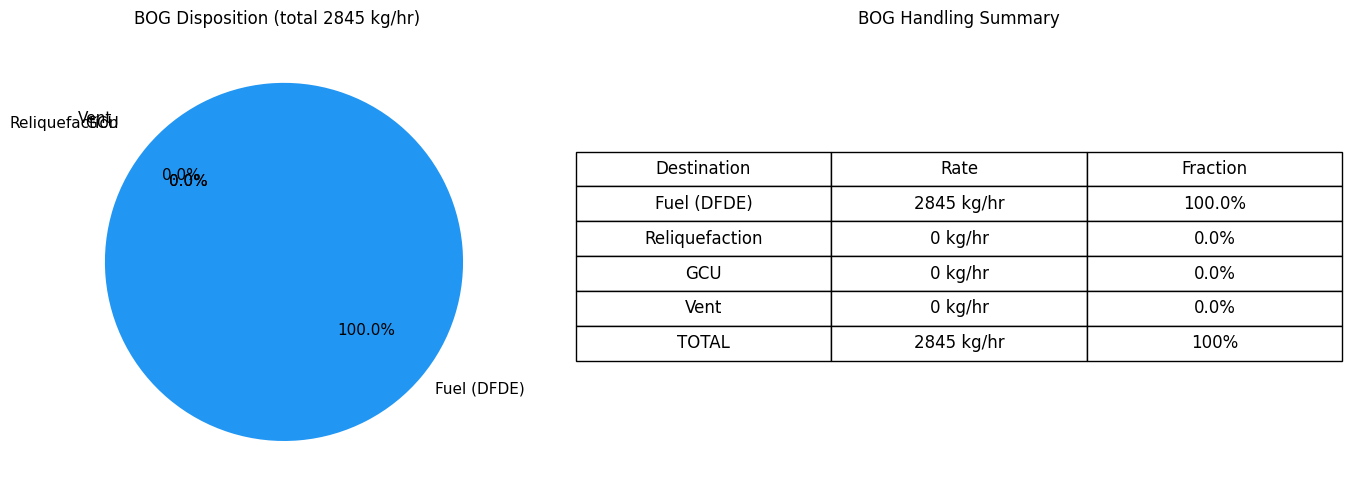

In [7]:
# BOG disposition from ship-level results
ship_results = list(ship.getShipResults())
last_sr = ship_results[-1]
avg_bog_rate = last_sr.totalBOGRate  # kg/hr total from all tanks

# Disposition from BOG network already calculated in ship results
bog_fuel = last_sr.bogToFuel
bog_reliq = last_sr.bogReliquefied
bog_gcu = last_sr.bogToGCU
bog_vent = last_sr.bogVented if hasattr(last_sr, "bogVented") else 0.0

labels = ['Fuel (DFDE)', 'Reliquefaction', 'GCU', 'Vent']
sizes = [bog_fuel, bog_reliq, bog_gcu, bog_vent]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
explode = (0.05, 0.05, 0.05, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sizes_nonzero = [(s if s > 0 else 0.001) for s in sizes]
axes[0].pie(sizes_nonzero, explode=explode, labels=labels, colors=colors,
           autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[0].set_title(f'BOG Disposition (total {avg_bog_rate:.0f} kg/hr)')

# Summary table
table_data = []
total_disp = sum(sizes)
for lbl, sz in zip(labels, sizes):
    frac = f'{sz/total_disp*100:.1f}%' if total_disp > 0 else '0%'
    table_data.append([lbl, f'{sz:.0f} kg/hr', frac])
table_data.append(['TOTAL', f'{total_disp:.0f} kg/hr', '100%'])
axes[1].axis('off')
tbl = axes[1].table(cellText=table_data,
                    colLabels=['Destination', 'Rate', 'Fraction'],
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 1.8)
axes[1].set_title('BOG Handling Summary')

plt.tight_layout()
plt.savefig('figures/lng_bog_handling.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion:**

- **Observation:** The majority of BOG is consumed as fuel for the dual-fuel diesel-electric
  (DFDE) propulsion, with the remainder routed to reliquefaction or GCU.
- **Physical mechanism:** DFDE engines operate on BOG-diesel dual-fuel mode, consuming
  the methane-rich vapor. Reliquefaction uses a nitrogen refrigeration cycle to condense
  excess BOG back to liquid.
- **Engineering implication:** Matching BOG supply with fuel demand is critical for the
  vessel's boil-off management. Over-production leads to GCU usage (economic loss);
  under-production requires forcing vaporization.
- **Recommendation:** Size reliquefaction capacity for peak BOG rates in warm waters.
  Consider slow steaming to reduce fuel demand and build BOG buffer for cold approaches.

## 5. Voyage Summary

Compare loading (departure) vs discharge (arrival) quality for contractual compliance.

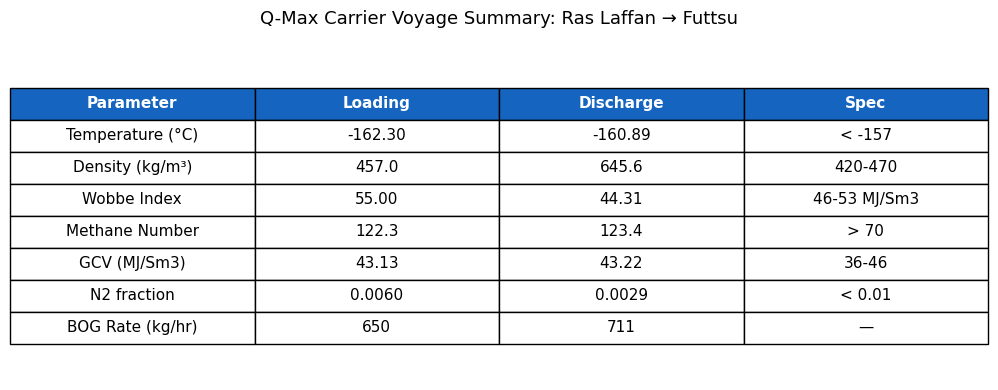


Total cargo loss: 0.74%
  (Typical industry range: 0.08-0.15% per day)
  (Over 20 days: 2.0-3.0% expected)


In [8]:
sc0 = tank_scenarios[0]  # representative tank
r_list = list(sc0.getResults())
r0 = r_list[1] if len(r_list) > 1 else r_list[0]  # skip step 0 if mass=0
rN = r_list[-1]

# Get nitrogen fraction from liquid composition map
def get_n2(r):
    comp = dict(r.getLiquidComposition())
    return comp.get('nitrogen', 0.0)

summary = [
    ['Parameter',       'Loading',                       'Discharge',                      'Spec'],
    ['Temperature (\u00b0C)', f'{r0.getTemperature()-273.15:.2f}', f'{rN.getTemperature()-273.15:.2f}', '< -157'],
    ['Density (kg/m\u00b3)', f'{r0.getDensity():.1f}',        f'{rN.getDensity():.1f}',          '420-470'],
    ['Wobbe Index',     f'{r0.getWobbeIndex():.2f}',     f'{rN.getWobbeIndex():.2f}',       '46-53 MJ/Sm3'],
    ['Methane Number',  f'{r0.getMethaneNumber():.1f}',   f'{rN.getMethaneNumber():.1f}',    '> 70'],
    ['GCV (MJ/Sm3)',    f'{r0.getGcvVolumetric():.2f}',  f'{rN.getGcvVolumetric():.2f}',    '36-46'],
    ['N2 fraction',     f'{get_n2(r0):.4f}',             f'{get_n2(rN):.4f}',               '< 0.01'],
    ['BOG Rate (kg/hr)', f'{r0.getBogMassFlowRate():.0f}', f'{rN.getBogMassFlowRate():.0f}', '\u2014'],
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tbl = ax.table(cellText=summary[1:], colLabels=summary[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)

# Color headers
for j in range(4):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Q-Max Carrier Voyage Summary: Ras Laffan \u2192 Futtsu', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('figures/lng_ship_voyage_summary.png', dpi=150, bbox_inches='tight')
plt.show()

initial_mass = r0.getLiquidMass()
final_mass = rN.getLiquidMass()
if initial_mass > 0:
    cargo_loss = (1 - final_mass / initial_mass) * 100
else:
    cargo_loss = 0.0
print(f"\nTotal cargo loss: {cargo_loss:.2f}%")
print(f"  (Typical industry range: 0.08-0.15% per day)")
print(f"  (Over {480/24:.0f} days: {0.10*480/24:.1f}-{0.15*480/24:.1f}% expected)")


**Discussion:**

- **Observation:** The composition shifts toward heavier components as methane and nitrogen
  preferentially evaporate. Wobbe Index and GCV increase while Methane Number decreases.
- **Physical mechanism:** Methane (bp -161.5°C) and nitrogen (bp -195.8°C) have the
  highest vapor pressures and boil off first. Ethane (bp -88.6°C) and propane (bp -42°C)
  remain in the liquid, enriching it.
- **Engineering implication:** The receiving terminal must ensure the aged LNG still meets
  pipeline specifications. Contracts typically define acceptable WI, GCV, and MN ranges.
- **Recommendation:** For long voyages, include a quality prediction model in commercial
  contracts. Blend aged LNG with lean cargoes to meet specs if needed.

## 6. References

- Miana, M. et al. (2010). "Calculation models for prediction of LNG ageing
  during ship transportation." *Applied Energy*, 87(5), 1687-1700.
- Migliore, C. et al. (2017). "Weathering prediction model for stored LNG."
  *J. Natural Gas Science & Engineering*, 45, 38-46.
- NeqSim documentation: [LNG Ageing Package](../../docs/process/lng-ageing.md)
- See also: [LNG Ageing Basics](lng_ageing_basics.ipynb),
  [Advanced Features](lng_ageing_advanced.ipynb)